# IMDb Movie Review Sentiment Analysis — Simple RNN

Trains a sentiment classifier (Positive/Negative) on the [IMDb Dataset of 50K Movie Reviews](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews) using a Simple RNN with an Embedding layer.

**Before running:** download `IMDB_Dataset.csv` from the link above and place it in the same folder as this notebook (or update the path in the cell below).

**Pipeline:**
1. Load dataset
2. Text preprocessing (clean HTML/punctuation, tokenize, pad sequences)
3. Build a Simple RNN model with an Embedding layer
4. Train and evaluate
5. Predict on custom reviews
6. Save the trained model + tokenizer so you can reuse them later


In [1]:
!pip install tensorflow pandas scikit-learn matplotlib -q

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
import re
import string
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout, SpatialDropout1D, Input
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

I0000 00:00:1786068665.112596     541 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786068665.115632     541 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1786068686.675262     541 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1786068699.995925     541 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786068699.999201     541 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## 1. Load dataset

In [3]:
df = pd.read_csv("IMDB_Dataset.csv")  # place IMDB_Dataset.csv next to this notebook
print(f"Dataset shape: {df.shape}")
df["sentiment"].value_counts()

Dataset shape: (50000, 2)


sentiment
positive    25000
negative    25000
Name: count, dtype: int64

## 2. Text preprocessing

In [4]:
def clean_text(text: str) -> str:
    """Lowercase, strip HTML tags, remove punctuation/digits, collapse whitespace."""
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)                   # remove HTML tags (e.g. <br />)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)  # remove URLs
    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)  # remove punctuation
    text = re.sub(r"\d+", " ", text)                     # remove digits
    text = re.sub(r"\s+", " ", text).strip()              # collapse whitespace
    return text


df["cleaned_review"] = df["review"].apply(clean_text)
df["label"] = df["sentiment"].map({"positive": 1, "negative": 0})

print("RAW :", df["review"].iloc[0][:200])
print("CLEAN:", df["cleaned_review"].iloc[0][:200])

RAW : One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo
CLEAN: one of the other reviewers has mentioned that after watching just oz episode you ll be hooked they are right as this is exactly what happened with me the first thing that struck me about oz was its br


In [5]:
# Tokenization parameters
VOCAB_SIZE = 10000     # keep only the top N most frequent words
MAX_LEN = 120           # pad/truncate all reviews to this length (kept short: plain
                         # SimpleRNN suffers from vanishing gradients on long sequences)
OOV_TOKEN = "<OOV>"

# Train / val / test split (done on raw text before fitting tokenizer only on train)
X_train_text, X_temp_text, y_train, y_temp = train_test_split(
    df["cleaned_review"].values, df["label"].values,
    test_size=0.3, random_state=SEED, stratify=df["label"].values
)
X_val_text, X_test_text, y_val, y_test = train_test_split(
    X_temp_text, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
)

print(f"Train size: {len(X_train_text)}")
print(f"Val size:   {len(X_val_text)}")
print(f"Test size:  {len(X_test_text)}")

Train size: 35000
Val size:   7500
Test size:  7500


In [6]:
# Fit tokenizer only on training data to avoid leakage
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_val_seq = tokenizer.texts_to_sequences(X_val_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="pre", truncating="post")
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding="pre", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="pre", truncating="post")

print(f"Padded training shape: {X_train_pad.shape}")
print(f"Sample padded sequence:\n{X_train_pad[0][:30]}")

# Save tokenizer for later inference use
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

Padded training shape: (35000, 120)
Sample padded sequence:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


## 3. Build the Simple RNN model

Design notes (found through iteration — see the project README for the full story):
- A **single** SimpleRNN layer is used deliberately: stacking multiple SimpleRNN layers, or using long sequences, makes the vanishing-gradient problem much worse and the model fails to learn at all.
- **`mask_zero=True` + pre-padding (`padding="pre"`)**: without masking, the RNN treats padding tokens as real input. For short reviews, the long run of padding steps washes out the signal from the real words. Masking tells the RNN to skip padding steps; pre-padding also keeps the real content as the *last* thing the RNN sees before predicting.
- **`unroll=True`**: forces a static (unrolled) graph instead of a dynamic loop — this is what allows the trained model to later export cleanly to TensorFlow Lite without needing TensorFlow's "Flex ops" delegate.
- **SpatialDropout1D + Dropout + light L2** keep the model from overfitting within a couple of epochs.
- **Gradient clipping (`clipnorm`)** keeps SimpleRNN's exploding-gradient tendency in check.


In [7]:
EMBEDDING_DIM = 32

model = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, mask_zero=True),
    SpatialDropout1D(0.2),
    SimpleRNN(32, activation="tanh", unroll=True),
    Dropout(0.5),
    Dense(16, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    Dropout(0.3),
    Dense(1, activation="sigmoid"),
])

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.0)

model.compile(
    loss="binary_crossentropy",
    optimizer=optimizer,
    metrics=["accuracy"],
)

model.summary()

E0000 00:00:1786068719.433477     541 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 120, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 120, 32)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,625 (1.23 MB)

 Trainable params: 322,625 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Train and evaluate

In [8]:
early_stop = EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)

EPOCHS = 12
BATCH_SIZE = 256

history = model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=2,
)

Epoch 1/12


E0000 00:00:1786068734.516729     541 util.cc:131] oneDNN supports DT_BOOL only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


137/137 - 23s - 169ms/step - accuracy: 0.6322 - loss: 0.6345 - val_accuracy: 0.7953 - val_loss: 0.4792


Epoch 2/12


137/137 - 8s - 55ms/step - accuracy: 0.8083 - loss: 0.4662 - val_accuracy: 0.8184 - val_loss: 0.4318


...

137/137 - 10s - 75ms/step - accuracy: 0.8727 - loss: 0.3424 - val_accuracy: 0.8308 - val_loss: 0.4572


Epoch 5/12


137/137 - 10s - 76ms/step - accuracy: 0.8777 - loss: 0.3341 - val_accuracy: 0.8357 - val_loss: 0.4323


Epoch 6/12


137/137 - 9s - 68ms/step - accuracy: 0.8892 - loss: 0.3032 - val_accuracy: 0.8299 - val_loss: 0.4805


In [9]:
test_loss, test_acc = model.evaluate(X_test_pad, y_test, verbose=0)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

y_pred_prob = model.predict(X_test_pad, verbose=0).ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["negative", "positive"]))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Test Loss:     0.3902
Test Accuracy: 0.8368



Classification Report:
              precision    recall  f1-score   support

    negative       0.83      0.84      0.84      3750
    positive       0.84      0.83      0.84      3750

    accuracy                           0.84      7500
   macro avg       0.84      0.84      0.84      7500
weighted avg       0.84      0.84      0.84      7500

Confusion Matrix:
[[3149  601]
 [ 623 3127]]


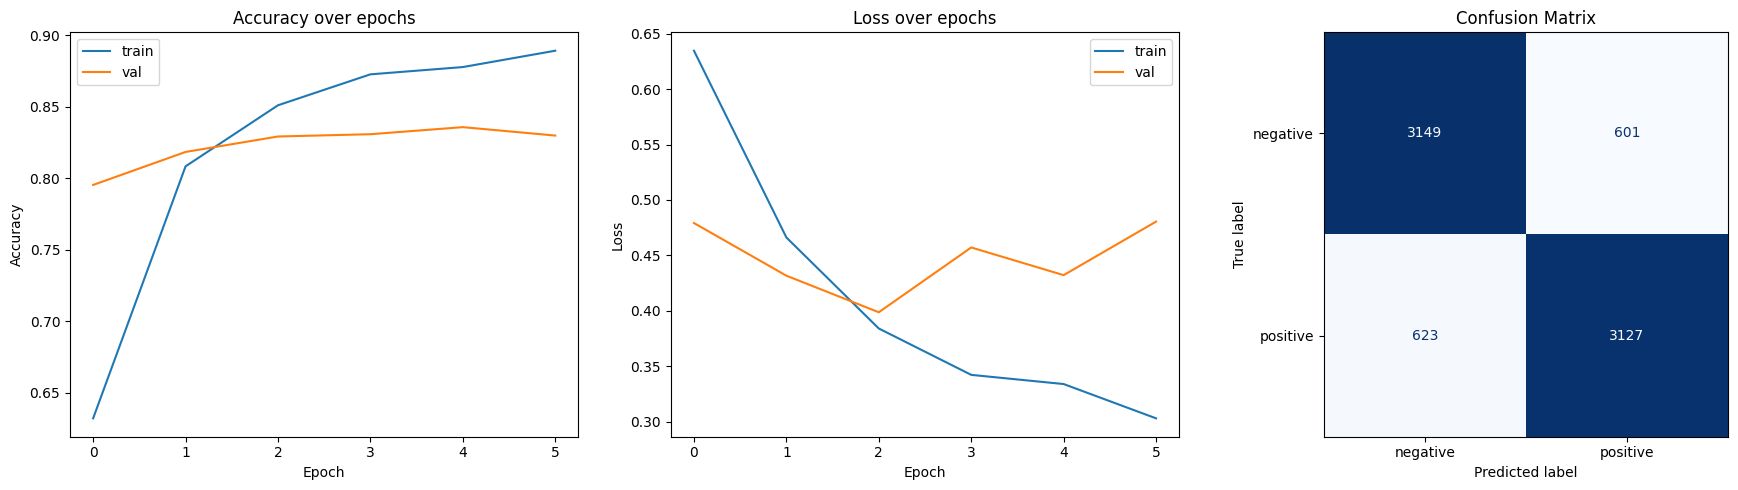

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history.history["accuracy"], label="train")
axes[0].plot(history.history["val_accuracy"], label="val")
axes[0].set_title("Accuracy over epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history.history["loss"], label="train")
axes[1].plot(history.history["val_loss"], label="val")
axes[1].set_title("Loss over epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["negative", "positive"])
disp.plot(ax=axes[2], cmap="Blues", colorbar=False)
axes[2].set_title("Confusion Matrix")

plt.tight_layout()
plt.savefig("training_results.png", dpi=150)
plt.show()

In [11]:
# Save the trained model
model.save("simple_rnn_imdb.keras")
print("Saved model to simple_rnn_imdb.keras")

Saved model to simple_rnn_imdb.keras


## 5. Predict on custom reviews

In [12]:
def predict_sentiment(text: str) -> tuple:
    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding="pre", truncating="post")
    prob = model.predict(padded, verbose=0)[0][0]
    label = "Positive" if prob >= 0.5 else "Negative"
    return label, float(prob)


custom_reviews = [
    "This movie was an absolute masterpiece. The acting, the story, everything was perfect!",
    "Waste of time. The plot made no sense and the acting was terrible.",
    "I really enjoyed this film, the cinematography was beautiful and the pacing kept me hooked.",
    "One of the worst movies I have ever seen. Boring, predictable, and poorly directed.",
    "A decent watch, not the best but definitely entertaining with a few great performances.",
    "Absolutely horrible. I want my two hours back. Terrible script and awful direction.",
    "Loved it!",
    "That was a weird movie.",
    "I hate that movie.",
    "Amazing film.",
    "Terrible.",
]

for review in custom_reviews:
    label, prob = predict_sentiment(review)
    print(f"Review: {review}")
    print(f"  -> Predicted Sentiment: {label}  (confidence: {prob:.4f})\n")

Review: This movie was an absolute masterpiece. The acting, the story, everything was perfect!
  -> Predicted Sentiment: Positive  (confidence: 0.8147)

Review: Waste of time. The plot made no sense and the acting was terrible.
  -> Predicted Sentiment: Negative  (confidence: 0.0123)



Review: I really enjoyed this film, the cinematography was beautiful and the pacing kept me hooked.
  -> Predicted Sentiment: Positive  (confidence: 0.9465)

Review: One of the worst movies I have ever seen. Boring, predictable, and poorly directed.
  -> Predicted Sentiment: Negative  (confidence: 0.0153)



Review: A decent watch, not the best but definitely entertaining with a few great performances.
  -> Predicted Sentiment: Positive  (confidence: 0.8664)

Review: Absolutely horrible. I want my two hours back. Terrible script and awful direction.
  -> Predicted Sentiment: Negative  (confidence: 0.0145)



Review: Loved it!
  -> Predicted Sentiment: Positive  (confidence: 0.7688)

Review: That was a weird movie.
  -> Predicted Sentiment: Negative  (confidence: 0.4670)



Review: I hate that movie.
  -> Predicted Sentiment: Positive  (confidence: 0.5757)

Review: Amazing film.
  -> Predicted Sentiment: Positive  (confidence: 0.7716)



Review: Terrible.
  -> Predicted Sentiment: Negative  (confidence: 0.1840)



## Try your own review

Type anything in the cell below and re-run it.

In [13]:
your_review = "Type your own movie review here!"
label, prob = predict_sentiment(your_review)
print(f"{label} (confidence: {prob:.4f})")

Positive (confidence: 0.5831)


## (Optional) Export to TensorFlow Lite for lightweight deployment

If you want to deploy this model somewhere with limited disk space (e.g. a free-tier host), export it to `.tflite` — this drops the runtime dependency from ~1.9GB (full TensorFlow) down to ~48MB (`ai-edge-litert`), with identical predictions.

In [14]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open("imdb_sentiment.tflite", "wb") as f:
    f.write(tflite_model)
print("Saved imdb_sentiment.tflite —", len(tflite_model), "bytes")

# Also export the tokenizer as plain JSON, so loading it doesn't require TensorFlow either
import json
tok_export = {
    "num_words": tokenizer.num_words,
    "oov_token": tokenizer.oov_token,
    "word_index": tokenizer.word_index,
}
with open("tokenizer.json", "w") as f:
    json.dump(tok_export, f)
print("Saved tokenizer.json")

INFO:tensorflow:Assets written to: /tmp/tmpifgkztwe/assets


INFO:tensorflow:Assets written to: /tmp/tmpifgkztwe/assets


Saved artifact at '/tmp/tmpifgkztwe'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 120), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  140145324057296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140145324057680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140145324059024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140145324058832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140145324060368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140145324059216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140145324060560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140145324057488: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1786068809.969657     541 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1786068809.969715     541 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1786068809.970392     541 reader.cc:83] Reading SavedModel from: /tmp/tmpifgkztwe
I0000 00:00:1786068809.972462     541 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1786068809.972486     541 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpifgkztwe
I0000 00:00:1786068810.000810     541 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1786068810.004700     541 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1786068810.109821     541 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpifgkztwe
I0000 00:00:1786068810.173907     541 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 203529 microseconds.
I0000 00:00:1786068810.361246     54

Saved imdb_sentiment.tflite — 1472968 bytes
Saved tokenizer.json
